In [49]:
import random
from itertools import product
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.quantum_info import Operator

In [11]:
SEED = 1234
backend = AerSimulator(seed_simulator=SEED)
sampler = Sampler(backend)

# Deutsch algorithm

> ### Deutsch's Problem
> **Input:** 
> * A Boolean function $f: \{0,1\} \rightarrow \{0,1\}$
>
> Since the function has only two possible inputs, it can only be either **constant** ($f(0) = f(1)$) or **balanced** ($f(0) \neq f(1)$).
>
> **Output:** 
> * $0$ if $f$ is **constant**.
> * $1$ if $f$ is **balanced**.

The input is represented as a function $f: \{0,1\} \rightarrow \{0,1\}$. We can think of this as a two bit chain $f(0)f(1)$. Every clasical algorithm needs at least two querys $f(0)$ and $f(1)$ to determine wether the function is constant or balanced. With Deutsch algorithm, we can solve this problem with just one query. We will follow the following procedure:

* **Initialization:** we prepare a 2 qbit circuit in the state $\ket{0}\ket{1}$:

$$
\ket{\psi_0} = \ket{0}\ket{1}
$$

* **Superposition:** we apply a Hadamard gate to both qubits:

$$
\ket{\psi_1}  = \frac{1}{\sqrt{2}} \sum_{x \in \{0,1\}} \ket{x} \otimes \ket{-} 
$$

* **Oracle:** we apply the oracle $U_f$. Due to the phase kickback mechanism, the auxiliary qubit remains in the state $\ket{-}$, while the value of $f(x)$ is encoded as a phase on the input qubit:

$$
\ket{\psi_2} = \frac{1}{\sqrt{2}} \sum_{x \in \{0,1\}} (-1)^{f(x)}\ket{x} \otimes \ket{-}
$$

That is:

$$
\ket{\psi_2} = \frac{1}{\sqrt{2}}\left((-1)^{f(0)}\ket{0} + (-1)^{f(1)}\ket{1}\right) \otimes \ket{-}
$$

* **Interference:** we apply another Hadamard gate to the input qubit. This causes constructive or destructive interference depending on whether $f(0)$ and $f(1)$ are equal or different:

$$
\ket{\psi_3} = H\left[\frac{1}{\sqrt{2}}\left((-1)^{f(0)}\ket{0} + (-1)^{f(1)}\ket{1}\right)\right] \otimes \ket{-}
$$

If $f(0) = f(1)$, the input qubit becomes $\ket{0}$. If $f(0) \neq f(1)$, the input qubit becomes $\ket{1}$, up to a global phase.

* **Measurement:** we measure the input qubit. If the result is $\ket{0}$, the function is constant. If the result is $\ket{1}$, the function is balanced.

There are only 4 posible functions {0,1} $\to $ {0,1}
| Case | Gates | Function $f(x)$ | Type |
| :---: | :--- | :--- | :--- |
| 0 | None | $f(x) = 0$ | Constant |
| 1 | X | $f(x) = 1$ | Constant |
| 2 | CNOT| $f(x) = x$ | Balanced |
| 3 | CNOT + X  | $f(x) = 1 - x$ | Balanced |

In [ ]:
def deutsch_oracle(case: int) -> QuantumCircuit:
    """
    Implements the Deutsch oracle for a single qubit given one of the 4 posible cases.
    """
    # Validate input
    if case not in range(4):
        raise ValueError("Case must be an integer between 0 and 3.")

    # Create the quantum circuit
    qc = QuantumCircuit(2)

    # Implement the oracle
    if case in [2, 3]:
        qc.cx(0, 1)
    if case in [3, 4]:
        qc.x(1)
        
    return qc

def deutsch_algorithm(case: int) -> QuantumCircuit:
    """
    Implements the Deutchs algorithm given one of the 4 posible cases.
    """
    # Create the quantum circuit
    qc = QuantumCircuit(2, 1)
    
    # Initialization
    qc.x(1) 
    qc.barrier()

    # Superposition
    qc.h([0,1])
    qc.barrier()
    
    # Oracle
    oracle = deutsch_oracle(case)
    qc.compose(oracle, inplace=True) 
    qc.barrier()

    # Interference
    qc.h(0) 

    # Measurement
    qc.measure(0,0) 

    return qc

##############################
Case  0
##############################
The function is constant
Measurement 0 -> the algorithm guessed that the function is constant


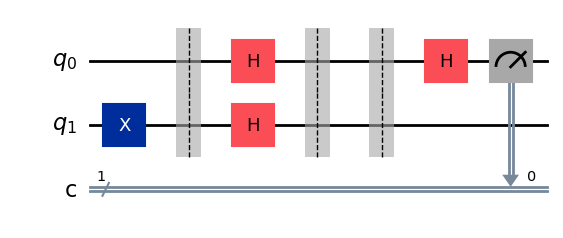

##############################
Case  1
##############################
The function is constant
Measurement 0 -> the algorithm guessed that the function is constant


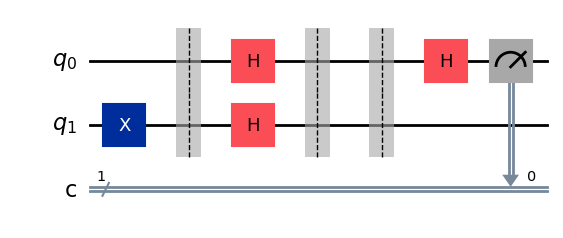

##############################
Case  2
##############################
The function is balanced
Measurement 1 -> the algorithm guessed that the function is balanced


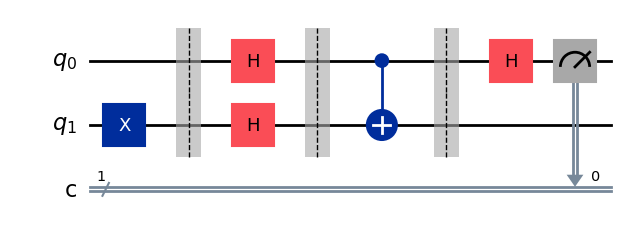

##############################
Case  3
##############################
The function is balanced
Measurement 1 -> the algorithm guessed that the function is balanced


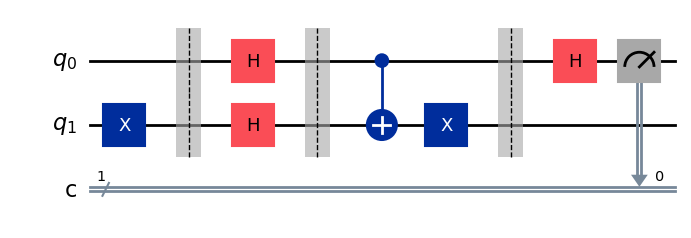

In [23]:
# Evaluate for all 4 posible cases
qc_list = []
cases = range(4)
for case in cases:
    qc = deutsch_algorithm(case)
    qc_list.append(qc)

# Run the circuits in a single batch
job = sampler.run(qc_list, shots=1)
results = job.result()

for case in cases:
    print(30 * "#")
    print("Case ", case)
    print(30 * "#")

    # Get the measured bit
    bit = results[case].data.c.get_bitstrings()[0]
    
    if case in [0, 1]:
        print("The function is constant") 
    else:
        print("The function is balanced") 

    if bit == "0":
        print("Measurement 0 -> the algorithm guessed that the function is constant") # Result |0> means f(0) = f(1)
    else:
        print("Measurement 1 -> the algorithm guessed that the function is balanced") # Result |1> means f(0) != f(1)

    display(qc_list[case].draw("mpl"))

The results show that Deutsch's algorithm correctly identifies the four possible cases. Constant functions are measured as $0$, while balanced functions are measured as $1$, matching the expected theoretical behavior.

# Deutsch-Jotza algorithm

> ### Deutsch-Jozsa Problem
> **Input:**  
> * An $n$-bit Boolean function $f: \{0,1\}^n \rightarrow \{0,1\}$
>
> **Promise:**  
> * $f$ is guaranteed to be either **constant** or **balanced**.
> * Constant means that $f(x)$ has the same value for all possible inputs $x$.
> * Balanced means that $f(x) = 0$ for exactly half of the inputs and $f(x) = 1$ for the other half.
>
> **Output:**  
> * $0$ if $f$ is **constant**.
> * $1$ if $f$ is **balanced**.

The Deutsch-Jozsa algorithm represents a powerful generalization of the original Deutsch algorithm, extending its capabilities from a single-bit input to an $n$-bit string $f: \{0,1\}^n \to \{0,1\}$. In a classical scenario, to determine with 100% certainty whether the function is constant or balanced, we would need $2^{n-1} + 1$ queries in the worst-case scenario. If we query half of the possible inputs and they all return the same value, we still wouldn't know if the remaining half contains a different value (balanced) or the same value (constant).Using the  Deutsch-Jotza algorithm, we can solve this problem with just one query. We will follow the following procedure:
* **Initialization:** we prepare a $n+1$ qbit circuit with $n$ input qbits in the $\ket{0}$ state and one auxiliary qbit in the $\ket{1}$ state. That way, the initial state is:
$$\ket{\psi_0}=\ket{0}^{\otimes n}\ket{1}$$
* **Superposition:** we apply a Hadamard gate to all qbits ($H^{\otimes n+1}$). The $n$ input qbits become the superposition of all posible states and the auxiliar qbit becomes $\ket-$. The state becomes:
$$\ket{\psi_1} = \frac{1}{\sqrt{2^n}} \sum_{x \in \{0,1\}^n} \ket{x} \otimes \ket-$$
* **Oracle:** we apply the oracle to the qbits. Due to the phase kickback mechanism, the $\ket{-}$ state of the auxiliary qubit remains unchanged, but the phase $(-1)^{f(x)}$ is shifted onto the $n$ input qbits:
$$\ket{\psi_2} = \frac{1}{\sqrt{2^n}} \sum_{x \in \{0,1\}^n} (-1)^{f(x)}\ket{x} \otimes \ket-$$
* **Interference:** Apply Hadamard gates ($H^{\otimes n}$) to the $n$ input qubits to cause constructive or destructive interference.
$$\ket{\psi_3} = \frac{1}{2^n} \sum_{x \in \{0,1\}^n} \sum_{y \in \{0,1\}^n} (-1)^{f(x) + x \cdot y} \ket{y} \otimes \ket{-}$$
* **Measurement:** We measure the $n$ input qbits. If the result is the all zero string $\ket{00...0}$ the function is constant, otherwise, the function is balanced.
 

To implement the Deutsch-Jozsa algorithm for a general Boolean function, we need to build an oracle $f(x)$. In this implementation, the oracle receives a list of bitstrings corresponding to the inputs that should return $1$. For each bitstring, we temporarily transform that input into the all-ones state using $X$ gates, apply a multi-controlled $X$ gate targeting the auxiliary qubit, and then undo the transformation. Since the auxiliary qubit is prepared in the state $\ket{-}$, flipping it produces a phase kickback effect, adding a phase $(-1)^{f(x)}$ to the corresponding input state.

In [80]:
def dj_oracle(nqbits: int, bitstrings_list: list[str]) -> QuantumCircuit:
    """
    Builds a Deutsch-Jozsa oracle from a list that contains all the inputs x for which f(x) = 1.
    """
    # Build the circuit
    qc = QuantumCircuit(nqbits + 1)

    # If the function is never 1, return the identity oracle
    if len(bitstrings_list) == 0:
        return qc

    for bitstring in bitstrings_list:
        # Flip all the zeros
        for i, bit in enumerate(bitstring):
            if bit == "0":
                qc.x(i)

        # Apply the multi-controlled x
        qc.mcx(list(range(nqbits)), nqbits)

        # Undo the flips
        for i, bit in enumerate(bitstring):
            if bit == "0":
                qc.x(i)
        qc.barrier()

    return qc

def dj_algorithm(oracle: QuantumCircuit) -> QuantumCircuit:
    """
    Implements the Deutchs-Jotza algoritm given a oracle.
    """
    # Get the numbre of qbits (-1 because of aux qubit)
    nqbits = oracle.num_qubits - 1

    # Create the quantum circuit
    qc = QuantumCircuit(nqbits + 1, nqbits)
    
    # Initialization
    qc.x(nqbits) 
    qc.barrier()

    # Superposition
    qc.h(list(range(nqbits + 1)))
    qc.barrier()

    # Oracle
    qc.compose(oracle, inplace=True) 

    # Interference
    qc.h(list(range(nqbits))) 

    # Measurement
    qc.measure(list(range(nqbits)), list(range(nqbits))) 

    return qc

def build_bitstrings_list(nqbits: int, balanced: bool) -> list[str]:
    """
    Builds the list of input bitstrings for which the Boolean function f(x) returns 1.
    If  balanced, half of the possible inputs are selected to return 1.
    If constant, either no input returns 1 or all inputs return 1.
    """
    all_bitstrings = ["".join(bits) for bits in product("01", repeat=nqbits)]
    if balanced:
        half_size = len(all_bitstrings) // 2
        return random.sample(all_bitstrings, half_size) # f(x) = 0 for half of the inputs
    else:
        if random.choice([True, False]):
            return [] # f(x) = 0 for all x
        else:
            return all_bitstrings # f(x) = 1 for all x

##############################
The function is balanced
Measurement 111 -> the algorithm guessed that the function is balanced
##############################


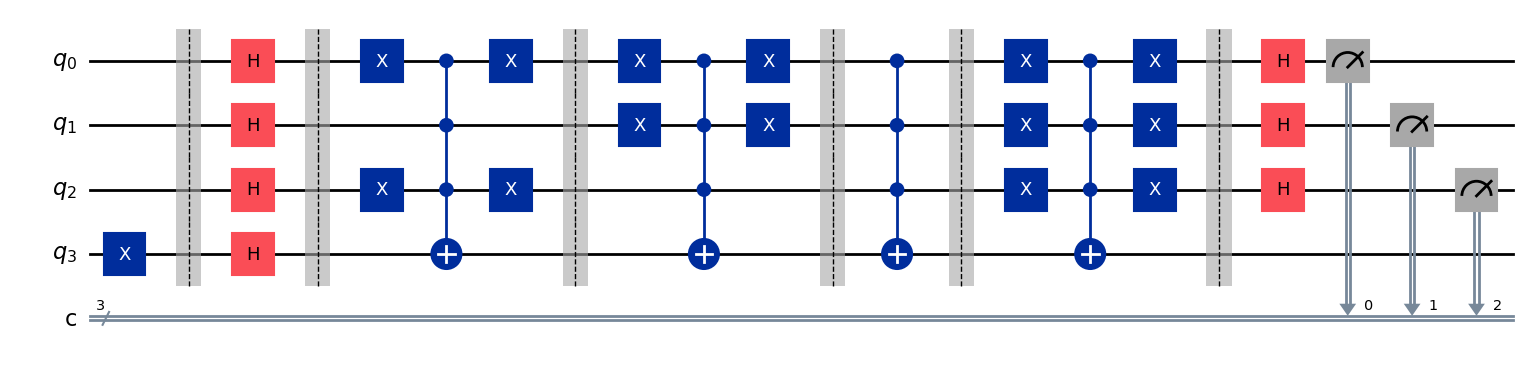

##############################
The function is constant
Measurement: 000 -> the algorithm guessed that the function is constant
##############################


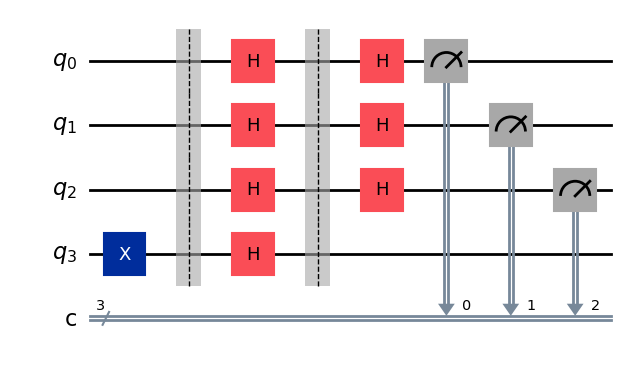

In [81]:
nqbits = 3
qc_list = []
balanced_list = [True, False]
for balanced in balanced_list:
    bitstrings_list = build_bitstrings_list(nqbits, balanced)
    oracle = dj_oracle(nqbits, bitstrings_list)
    qc = dj_algorithm(oracle)
    qc_list.append(qc)

# Run the circuits in a single batch
job = sampler.run(qc_list, shots=1)
results = job.result()

for i, balanced in enumerate(balanced_list):
    print(30 * "#")
    # Get the measured bit
    bit = results[i].data.c.get_bitstrings()[0]
    
    if not balanced:
        print("The function is constant") 
    else:
        print("The function is balanced") 

    if bit == "0" * nqbits:
        print(f"Measurement: {bit} -> the algorithm guessed that the function is constant")
    else:
        print(f"Measurement {bit} -> the algorithm guessed that the function is balanced")
    print(30 * "#")
    
    display(qc_list[i].draw("mpl"))


The results show that the Deutsch-Jozsa algorithm correctly distinguishes between constant and balanced functions with a single oracle query. When the measurement is $000$, the function is identified as constant; otherwise, it is identified as balanced, as expected.

# Bernstein-Vazirani algorithm

> ### Bernstein-Vazirani Problem
> **Input:**  
> * An $n$-bit Boolean function $f: \{0,1\}^n \rightarrow \{0,1\}$
>
> **Promise:**  
> * The function is guaranteed to hide a secret bitstring $b = b_1 \ldots b_n$, and its output is computed as:
>
>   $$
>   f(x_1, \ldots, x_n) = x_1b_1 \oplus \cdots \oplus x_nb_n
>   $$
>
>   where $\oplus$ denotes addition modulo 2.
>
> **Output:**  
> * The hidden bitstring $b$.

Classically, we would need to evaluate the function several times to recover the full bitstring $b$, testing inputs such as $f(1,0,\ldots,0)$, $f(0,1,\ldots,0)$, and so on. However, the Bernstein-Vazirani algorithm can recover the entire hidden bitstring with a single oracle query.